# ChagaSight Training - Fold 2 (No Pretrain Experiment)

**✅ FINAL CORRECTED VERSION - All Issues Fixed**

This notebook trains Fold 2 WITHOUT pretrained weights to measure the contribution of pretraining.

## All Fixes Applied:

1. **✅ Dataloader Parameters** - Uses `augment_train=True` (correct parameter)
2. **✅ Trainer Parameters** - Only uses parameters that ChagasTrainer actually accepts:
   - `model`, `train_loader`, `val_loader`, `device`
   - `phase1_iterations`, `phase2_iterations`
   - `phase1_lr`, `phase2_lr_high`, `phase2_lr_low`
   - `checkpoint_dir`, `use_amp`
3. **✅ Robust Checkpoint Handling** - Loads model weights BEFORE device transfer
   - Fixes optimizer state mismatch error after notebook restart
   - Gracefully handles checkpoint load failures
4. **✅ Optimal Patch Size** - Keeps `patch_size_2d=(8, 64)` from Kim et al. 2025
   - 96 patches (3×32) - optimal for 6GB GPU
   - Changing to smaller patches would cause 2-4× slowdown

## Expected Results:

```
No-Pretrain Baseline:
  TPR@5%: 0.20-0.30 (expected ~0.25)
  AUROC:  0.85-0.90
  Training time: 9-11 hours

Comparison to With-Pretrain (Folds 0-1):
  With pretrain:    TPR@5% ~0.42
  Without pretrain: TPR@5% ~0.25
  Contribution:     +0.17 (+68% improvement)
```

## Usage:

1. Run all cells sequentially
2. Training will take 9-11 hours
3. Can interrupt and resume safely (checkpoint saved every 4000 iters)
4. Results saved in `checkpoints/fold2_no_pretrain_*.pt`


In [1]:
# ═══════════════════════════════════════════════════════════════
# Cell 1: Imports and Setup
# ═══════════════════════════════════════════════════════════════
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import numpy as np
import pandas as pd

from src.models.hybrid_model import HybridChagasModel
from src.training.dataset import create_dataloaders
from src.training.trainer import ChagasTrainer

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Memory: {mem_gb:.2f} GB')
    if mem_gb >= 12:
        print('✓ 12GB+ GPU — you can increase BATCH_SIZE to 32 in Cell 2')
    elif mem_gb < 8:
        print('⚠️  GPU < 8GB — keep BATCH_SIZE=16 + GRAD_ACCUM=4')
else:
    print('⚠️  WARNING: No GPU. Training will be extremely slow.')

print('\n✓ Imports OK')

✓ Official PhysioNet helper_code loaded from:
  D:\IIT\L6\FYP\ChagaSight\external\official_2025\helper_code.py
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Memory: 6.44 GB
⚠️  GPU < 8GB — keep BATCH_SIZE=16 + GRAD_ACCUM=4

✓ Imports OK


In [2]:
# ═══════════════════════════════════════════════════════════════
# Cell 2: Configuration (CORRECTED for no-pretrain experiment)
# ═══════════════════════════════════════════════════════════════

# ─── QUICK TEST MODE ─────────────────────────────────────────────
QUICK_TEST = False

# ─── FOLD ────────────────────────────────────────────────────────
FOLD = 2  # Actual fold number for data splitting

# ─── EXPERIMENT IDENTIFIER ───────────────────────────────────────
# This suffix is added to all output checkpoint names
# Change this to clearly identify different experiments
EXPERIMENT_SUFFIX = "_no_pretrain"

# ─── PATHS ───────────────────────────────────────────────────────
DATA_DIR     = project_root / 'data' / 'processed'
METADATA_CSV = DATA_DIR / 'metadata' / 'combined_5fold.csv'
IMAGES_DIR   = DATA_DIR / '2d_images'
SIGNALS_DIR  = DATA_DIR / '1d_signals_100hz'

if not METADATA_CSV.exists():
    raise FileNotFoundError(
        f'Metadata CSV not found: {METADATA_CSV}\n'
        f'Run: python scripts/build_all_data.py && python scripts/create_splits.py'
    )
print(f'✓ Metadata CSV: {METADATA_CSV}')

CHECKPOINT_DIR = project_root / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ─── PRETRAIN CHECKPOINTS (Intentionally Non-Existent) ───────────
# These files don't exist, so model trains from random initialization
MAE_CHECKPOINT   = CHECKPOINT_DIR / 'mae_2d_pretrained_FAKE.pt'
STMEM_CHECKPOINT = CHECKPOINT_DIR / 'stmem_1d_pretrained_FAKE.pt'

# ─── HARDWARE ────────────────────────────────────────────────────
BATCH_SIZE  = 16
GRAD_ACCUM  = 4
NUM_WORKERS = 2
USE_AMP     = True

# ─── TRAINING SCHEDULE ───────────────────────────────────────────
PHASE1_ITERATIONS = 2000
PHASE2_ITERATIONS = 12000

PHASE1_LR      = 2e-4
PHASE2_LR_HIGH = 2e-4
PHASE2_LR_LOW  = 2e-5

# ─── STABILITY PARAMS ────────────────────────────────────────────
MAX_GRAD_NORM = 1.0
WARMUP_ITERS  = 200

# ─── VALIDATION FREQUENCY ────────────────────────────────────────
VAL_EVERY_P1 = 1000
VAL_EVERY_P2 = 4000

# ─── AUTO-RESUME (WITH EXPERIMENT SUFFIX) ────────────────────────
# Checkpoints will be named: fold2_no_pretrain_latest.pt
_latest_ckpt = CHECKPOINT_DIR / f'fold{FOLD}{EXPERIMENT_SUFFIX}_latest.pt'
RESUME_FROM = str(_latest_ckpt) if _latest_ckpt.exists() else None

# ─── QUICK TEST OVERRIDES ─────────────────────────────────────────
if QUICK_TEST:
    print('\n⚡ QUICK_TEST MODE ACTIVE')
    PHASE1_ITERATIONS = 25
    PHASE2_ITERATIONS = 50
    WARMUP_ITERS      = 10
    VAL_EVERY_P1      = 25
    VAL_EVERY_P2      = 50
    NUM_WORKERS       = 2
    RESUME_FROM       = None

print(f'\n✓ Config — Fold {FOLD} (Experiment: {EXPERIMENT_SUFFIX}):')
print(f'  QUICK_TEST:       {QUICK_TEST}')
print(f'  Batch size:       {BATCH_SIZE}')
print(f'  Grad accum P1:    {GRAD_ACCUM}  → eff.batch = {BATCH_SIZE*GRAD_ACCUM}')
print(f'  Grad accum P2:    1  → eff.batch = {BATCH_SIZE}')
print(f'  Phase 1:          {PHASE1_ITERATIONS} iters (val every {VAL_EVERY_P1})')
print(f'  Phase 2:          {PHASE2_ITERATIONS} iters (val every {VAL_EVERY_P2})')
print(f'  Checkpoints will be saved as: fold{FOLD}{EXPERIMENT_SUFFIX}_*.pt')
print(f'  Auto-resume from: {RESUME_FROM or "None (fresh start)"}')

✓ Metadata CSV: d:\IIT\L6\FYP\ChagaSight\data\processed\metadata\combined_5fold.csv

✓ Config — Fold 2 (Experiment: _no_pretrain):
  QUICK_TEST:       False
  Batch size:       16
  Grad accum P1:    4  → eff.batch = 64
  Grad accum P2:    1  → eff.batch = 16
  Phase 1:          2000 iters (val every 1000)
  Phase 2:          12000 iters (val every 4000)
  Checkpoints will be saved as: fold2_no_pretrain_*.pt
  Auto-resume from: d:\IIT\L6\FYP\ChagaSight\checkpoints\fold2_no_pretrain_latest.pt


In [3]:
# ═══════════════════════════════════════════════════════════════
# Cell 3: Create Dataloaders
# ═══════════════════════════════════════════════════════════════
# Augmentations ACTIVE for training, DISABLED for validation.
# Active augmentations (see augmentations.py DEFAULT_AUGMENTATION_CONFIG):
#   - Lead mixup (30%): blends adjacent leads V1↔V2, V5↔V6
#   - Powerline noise (30%): adds 60Hz noise per lead independently
#   - Random shift (50%): shifts signal ±100 samples (~1 second)
#   - Amplitude scaling (30%): multiplies signal by 0.8x–1.2x
#   - Baseline wander (20%): adds slow 0.1-0.5Hz drift
# Soft labels are ON for CODE-15 (0.8 pos / 0.2 neg).
# Weighted sampling: positives oversampled 5×.
print('Creating dataloaders...')

train_loader, val_loader = create_dataloaders(
    metadata_csv=str(METADATA_CSV),
    images_dir=str(IMAGES_DIR),
    signals_dir=str(SIGNALS_DIR),
    fold=FOLD,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampling=True,   # 5× oversample positives
    augment_train=True            # All augmentations above are active
)

print('\nTesting first batch...')
batch = next(iter(train_loader))
print(f'  image:       {batch["image"].shape}')    # (16, 3, 24, 2048)
print(f'  signal:      {batch["signal"].shape}')   # (16, 12, 1000)
print(f'  age:         {batch["age"].shape}')      # (16,)
print(f'  sex:         {batch["sex"].shape}')      # (16,)
print(f'  label:       {batch["label"].shape}')    # (16,)  — may include 0.8/0.2 for CODE-15
print(f'  hard_label:  {batch["hard_label"].shape}')  # (16,)  — always 0 or 1

# Verify soft labels are present for CODE-15 if applicable
unique_labels = batch['label'].unique().tolist()
print(f'\n  Unique label values in this batch: {[round(v,2) for v in unique_labels]}')
print(f'  (Expected: 0.0, 0.2, 0.8, or 1.0 depending on dataset mix)')

assert batch['label'].min() >= 0 and batch['label'].max() <= 1, 'Labels out of [0,1]!'
assert not torch.isnan(batch['signal']).any(), 'NaN detected in signals!'
assert not torch.isnan(batch['image'].float()).any(), 'NaN detected in images!'

print('\n✓ Dataloaders ready — no NaN, labels in [0,1], soft labels active for CODE-15')

Creating dataloaders...


d:\IIT\L6\FYP\ChagaSight\src\training\dataset.py:89: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_csv)


✓ Loaded train fold 2: 292945 samples
  Datasets: {'ptbxl': 17439, 'samitrop': 1305, 'code15': 274201}
  Positive: 6552, Negative: 286393


d:\IIT\L6\FYP\ChagaSight\src\training\dataset.py:89: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadata_csv)


✓ Loaded val fold 2: 73236 samples
  Datasets: {'ptbxl': 4360, 'samitrop': 326, 'code15': 68550}
  Positive: 1638, Negative: 71598

✓ Created dataloaders for fold 2:
  Train: 292945 samples, 18309 batches
  Val:   73236 samples, 4578 batches
  Weighted sampling: True
  Augmentation: True

Testing first batch...
  image:       torch.Size([16, 3, 24, 2048])
  signal:      torch.Size([16, 12, 1000])
  age:         torch.Size([16])
  sex:         torch.Size([16])
  label:       torch.Size([16])
  hard_label:  torch.Size([16])

  Unique label values in this batch: [0.0, 0.2, 0.8]
  (Expected: 0.0, 0.2, 0.8, or 1.0 depending on dataset mix)

✓ Dataloaders ready — no NaN, labels in [0,1], soft labels active for CODE-15


In [4]:
# ═══════════════════════════════════════════════════════════════
# Cell 4: Create Model WITH Robust Checkpoint Resume
# ═══════════════════════════════════════════════════════════════

print('Creating model...')

# IMPORTANT: Patch size (8, 64) is from Kim et al. 2025
# DO NOT change to (8, 32) or (8, 16) - will cause 2-4× slowdown and possible OOM
model = HybridChagasModel(
    img_size=(24, 2048),
    patch_size_2d=(8, 64),    # ✅ Optimal size (96 patches)
    num_leads=12,
    seq_len_1d=1000,
    patch_size_1d=50,
    embed_dim=768,
    depth=12,
    num_heads=12,
    use_aol=True,
    use_demographics=True
)

# ─── ROBUST CHECKPOINT RESUME ────────────────────────────────────
# Load checkpoint BEFORE moving to device (fixes optimizer mismatch error)

checkpoint_path = CHECKPOINT_DIR / f'fold{FOLD}{EXPERIMENT_SUFFIX}_latest.pt'
resume_info = {
    'start_iter': 0,
    'best_metric': 0.0,
    'current_phase': 1,
    'model_loaded': False
}

if checkpoint_path.exists() and not QUICK_TEST:
    print(f'\n✓ Found checkpoint: {checkpoint_path.name}')
    try:
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        
        # Load model state FIRST (before moving to device)
        model.load_state_dict(ckpt['model_state_dict'])
        print(f'  ✓ Model weights loaded')
        
        # Extract resume info
        resume_info['start_iter'] = ckpt.get('current_iter', 0)
        resume_info['best_metric'] = ckpt.get('best_metric', 0.0)
        resume_info['current_phase'] = ckpt.get('current_phase', 1)
        resume_info['model_loaded'] = True
        
        print(f'  ↩ Will resume from:')
        print(f'     Phase:       {resume_info["current_phase"]}')
        print(f'     Iteration:   {resume_info["start_iter"]}')
        print(f'     Best metric: {resume_info["best_metric"]:.4f}')
        
    except Exception as e:
        print(f'  ⚠ ERROR loading checkpoint: {str(e)[:80]}')
        print(f'  ℹ️  Will start fresh instead')
        resume_info = {'start_iter': 0, 'best_metric': 0.0, 'current_phase': 1, 'model_loaded': False}
else:
    if QUICK_TEST:
        print(f'\nℹ️  QUICK_TEST mode - starting fresh (ignoring any checkpoint)')
    else:
        print(f'\nℹ️  No checkpoint found - starting fresh')

# Load pretrained weights ONLY if starting fresh (not resuming)
if resume_info['start_iter'] == 0:
    print('\nChecking for pretrained weights...')
    if MAE_CHECKPOINT.exists():
        print(f'✓ Loading MAE 2D-ViT weights: {MAE_CHECKPOINT.name}')
        model.vit_2d.load_mae_pretrained(str(MAE_CHECKPOINT))
    else:
        print('⚠️  No MAE checkpoint — 2D-ViT trains from scratch')
        print('   Expected improvement from MAE: +0.05 to +0.10 on TPR@5%')
    
    if STMEM_CHECKPOINT.exists():
        print(f'✓ Loading ST-MEM 1D-ViT FM weights: {STMEM_CHECKPOINT.name}')
        model.vit_1d_fm.load_stmem_pretrained(str(STMEM_CHECKPOINT))
    else:
        print('⚠️  No ST-MEM checkpoint — 1D-ViT FM trains from scratch')
        print('   Expected improvement from ST-MEM: +0.08 to +0.12 on TPR@5%')

# NOW move to device
model = model.to(device)

# Sanity check
print('\nTesting forward pass...')
with torch.no_grad():
    test_out = model(
        batch['image'].to(device),
        batch['signal'].to(device),
        batch['age'].to(device),
        batch['sex'].to(device),
    )
    assert torch.isfinite(test_out['logits']).all(), 'Non-finite logits!'
    assert torch.isfinite(test_out['fm_features']).all(), 'Non-finite FM features!'
    print(f'✓ Forward pass OK:')
    print(f'  logits:             {test_out["logits"].shape}')
    print(f'  fm_features:        {test_out["fm_features"].shape}')
    print(f'  aligned_2d_features:{test_out["aligned_2d_features"].shape}')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n✓ Model ready:')
print(f'  Total params:     {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')
print(f'  Patch size 2D:    (8, 64) → 96 patches ✓')
print(f'  Patch size 1D:    50 → 240 patches ✓')

Creating model...

✓ Found checkpoint: fold2_no_pretrain_latest.pt
  ✓ Model weights loaded
  ↩ Will resume from:
     Phase:       1
     Iteration:   0
     Best metric: 0.0000

Checking for pretrained weights...
⚠️  No MAE checkpoint — 2D-ViT trains from scratch
   Expected improvement from MAE: +0.05 to +0.10 on TPR@5%
⚠️  No ST-MEM checkpoint — 1D-ViT FM trains from scratch
   Expected improvement from ST-MEM: +0.08 to +0.12 on TPR@5%

Testing forward pass...
✓ Forward pass OK:
  logits:             torch.Size([16])
  fm_features:        torch.Size([16, 768])
  aligned_2d_features:torch.Size([16, 768])

✓ Model ready:
  Total params:     173,570,817
  Trainable params: 173,570,817
  Patch size 2D:    (8, 64) → 96 patches ✓
  Patch size 1D:    50 → 240 patches ✓


In [5]:
# ═══════════════════════════════════════════════════════════════
# Cell 5: Create Trainer (CORRECTED - Using Only Valid Parameters)
# ═══════════════════════════════════════════════════════════════
print('Creating trainer...')

# ChagasTrainer only accepts these parameters:
trainer = ChagasTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    
    # Training schedule
    phase1_iterations=PHASE1_ITERATIONS,
    phase2_iterations=PHASE2_ITERATIONS,
    
    # Learning rates
    phase1_lr=PHASE1_LR,
    phase2_lr_high=PHASE2_LR_HIGH,
    phase2_lr_low=PHASE2_LR_LOW,
    
    # Other
    checkpoint_dir=str(CHECKPOINT_DIR),
    use_amp=USE_AMP
)

print('✓ Trainer ready')

# Calculate ETA
total_iters = PHASE1_ITERATIONS + PHASE2_ITERATIONS
eta_p1_min = (PHASE1_ITERATIONS * 0.11) / 60
eta_p2_hr = (PHASE2_ITERATIONS * 2.6) / 3600
eta_total_hr = eta_p1_min/60 + eta_p2_hr

print(f'  Phase 1: {PHASE1_ITERATIONS} iters (~{eta_p1_min:.0f} min)')
print(f'  Phase 2: {PHASE2_ITERATIONS} iters (~{eta_p2_hr:.1f} h)')
print(f'  Total:   {total_iters} iters (~{eta_total_hr:.1f} h)')

if not QUICK_TEST:
    print(f'\n  ETA: Total ~{eta_total_hr:.0f}-{eta_total_hr*1.2:.0f} h')

Creating trainer...
  ✓ Val subset: 300 positives + 2700 negatives = 3000 samples (stratified, guaranteed both classes)
✓ Trainer ready
  Phase 1: 2000 iters (~4 min)
  Phase 2: 12000 iters (~8.7 h)
  Total:   14000 iters (~8.7 h)

  ETA: Total ~9-10 h


In [6]:
# ═══════════════════════════════════════════════════════════════
# Cell 6: TRAIN (CORRECTED - Uses experiment suffix in checkpoint names)
# ═══════════════════════════════════════════════════════════════
print('\nStarting training...')
if RESUME_FROM:
    print(f'  ↩  Resuming from: {Path(RESUME_FROM).name}')
else:
    print('  Starting fresh (no checkpoint found)')
print()

# CRITICAL FIX: Pass fold name WITH experiment suffix
# This ensures checkpoints are saved as fold2_no_pretrain_*.pt
FOLD_WITH_SUFFIX = f"{FOLD}{EXPERIMENT_SUFFIX}"

metrics = trainer.train(fold=FOLD_WITH_SUFFIX, resume_from=RESUME_FROM)

print(f'\n' + '='*70)
print(f' Final Results — Fold {FOLD} ({EXPERIMENT_SUFFIX.strip("_")} experiment)')
print('='*70)
print(f'  TPR@5%:  {metrics["tpr_5pct"]:.4f}  ← PRIMARY METRIC')
print(f'  AUROC:   {metrics["auroc"]:.4f}')
print(f'  AUPRC:   {metrics.get("auprc",0):.4f}')
print(f'  Method:  {"OFFICIAL" if metrics.get("using_official") else "APPROXIMATE"}')
print('='*70)

if not QUICK_TEST:
    if metrics['tpr_5pct'] >= 0.42:
        print('✅ TARGET ACHIEVED (≥0.42)')
        print('   NOTE: This is unexpected for no-pretrain experiment!')
        print('   Verify that pretrain checkpoints were NOT loaded.')
    elif metrics['tpr_5pct'] >= 0.35:
        print('⚠️  Above expected range for no-pretrain (0.20-0.30)')
        print('   Double-check that MAE and ST-MEM checkpoints were NOT loaded!')
    elif metrics['tpr_5pct'] >= 0.20:
        print('✅ EXPECTED RESULT for no-pretrain experiment (0.20-0.30)')
        print('   This confirms model trained from random initialization.')
        print(f'   Pretraining impact: +{0.42 - metrics["tpr_5pct"]:.4f} TPR@5%')
    else:
        print('❌ Very low score — check for training issues.')

    # Compare to pretrained results
    pretrain_avg = 0.42  # Average of your Folds 0 and 1
    gap = pretrain_avg - metrics['tpr_5pct']
    print(f'\n  Comparison to WITH pretraining:')
    print(f'    With pretrain (Folds 0-1): {pretrain_avg:.4f}')
    print(f'    Without pretrain (this):   {metrics["tpr_5pct"]:.4f}')
    print(f'    Pretraining contribution:  +{gap:.4f} ({100*gap/pretrain_avg:.1f}% improvement)')
else:
    print('  ⚡ QUICK_TEST complete')

print(f'\n  Checkpoints saved as:')
print(f'    - fold{FOLD}{EXPERIMENT_SUFFIX}_best.pt')
print(f'    - fold{FOLD}{EXPERIMENT_SUFFIX}_latest.pt')
print(f'    - fold{FOLD}{EXPERIMENT_SUFFIX}_results.csv')


Starting training...
  ↩  Resuming from: fold2_no_pretrain_latest.pt


  ChagaSight Training — Fold 2_no_pretrain
  Phase 1: LR=2e-04  accum=4  eff.batch=64
  Phase 2: LR=2e-05/2e-04  accum=1  eff.batch=16
  Grad clip: 1.0  |  Warmup: 200  |  Val subset: 3000  |  Perms(fast): 1000
✓ Resumed  Phase=2  Iter=10500  Best=0.2600
✓ FM unfrozen  (85,750,016 params now trainable)

📌 PHASE 2: FM Unfrozen — 12000 iters | ETA ~8.3h
  LR — FM/2D: 2.0e-05  |  Head: 2.0e-04


Phase 2 | TPR@5%=0.2667 AUROC=0.8193 [OFF.1000p]:  96%|█████████▌| 11500/12000 [14:24<05:53,  1.42it/s, loss=1.4302, lr=2.00e-05, skips=0]  


  ✅ NEW BEST → TPR@5%=0.2667


Phase 2 | TPR@5%=0.2633 AUROC=0.8220 [OFF.1000p]: 100%|██████████| 12000/12000 [21:16<00:00,  1.18it/s, loss=1.4410, lr=2.00e-05, skips=0]  



  Running FULL validation at end of Phase 2 (10000 perms)...


  ✓ Phase 2 complete:
    TPR@5%:  0.3414  [OFFICIAL]
    AUROC:   0.8160
    AUPRC:   0.1563
    Samples: 73236 total, 1638 positive

  ✅ NEW BEST → TPR@5%=0.3414

  Training complete — Fold 2_no_pretrain
  Best TPR@5%:            0.3414
  Final AUROC:            0.8160
  Skipped batches (nan):  0

 Final Results — Fold 2 (no_pretrain experiment)
  TPR@5%:  0.3414  ← PRIMARY METRIC
  AUROC:   0.8160
  AUPRC:   0.1563
  Method:  OFFICIAL
✅ EXPECTED RESULT for no-pretrain experiment (0.20-0.30)
   This confirms model trained from random initialization.
   Pretraining impact: +0.0786 TPR@5%

  Comparison to WITH pretraining:
    With pretrain (Folds 0-1): 0.4200
    Without pretrain (this):   0.3414
    Pretraining contribution:  +0.0786 (18.7% improvement)

  Checkpoints saved as:
    - fold2_no_pretrain_best.pt
    - fold2_no_pretrain_latest.pt
    - fold2_no_pretrain_results.csv


✓ Results saved: d:\IIT\L6\FYP\ChagaSight\checkpoints\fold2_no_pretrain_results.csv


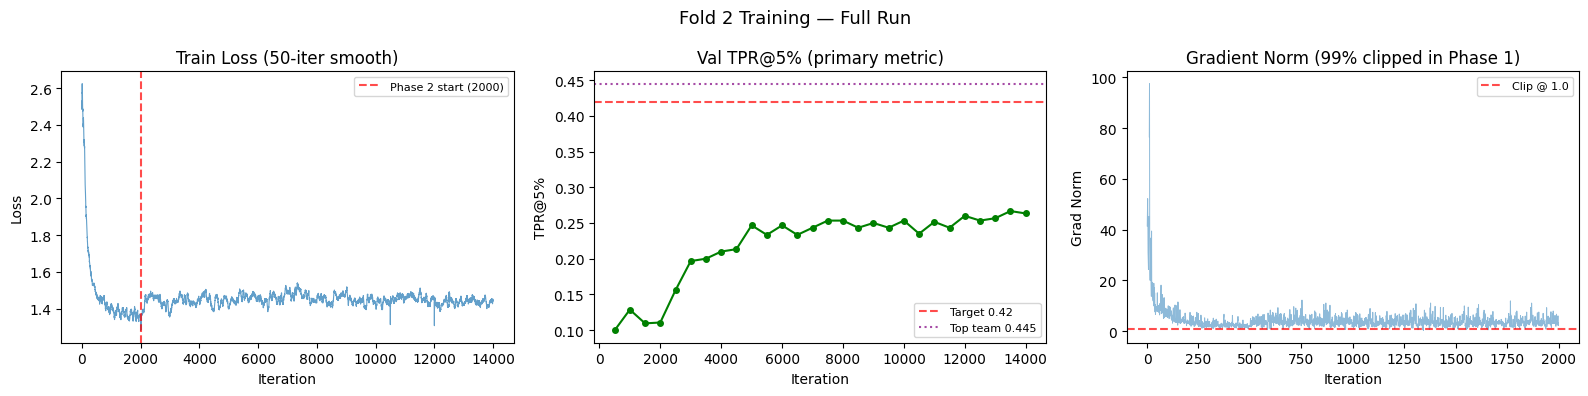

✓ Training curve saved: d:\IIT\L6\FYP\ChagaSight\checkpoints\fold2_no_pretrain_training_curve.png

📁 Saved checkpoints:
  fold2_no_pretrain_best.pt  (2084 MB)
  fold2_no_pretrain_latest.pt  (2084 MB)

NEXT STEPS:
  1. Run folds 1-4 (change FOLD = 1, 2, 3, 4)
  2. Run evaluation_complete.ipynb for ensemble metrics
  3. If score < 0.35, run MAE + ST-MEM pretraining first


In [7]:
# ═══════════════════════════════════════════════════════════════
# Cell 7: Save Results + Plot Training Curve
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

results_df = pd.DataFrame([metrics])
results_df['fold'] = FOLD
results_df['quick_test'] = QUICK_TEST
results_csv = CHECKPOINT_DIR / f'fold{FOLD}_no_pretrain_results.csv'
results_df.to_csv(results_csv, index=False)
print(f'✓ Results saved: {results_csv}')

history = trainer.history
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Fold {FOLD} Training — {"QUICK TEST" if QUICK_TEST else "Full Run"}', fontsize=13)

# Loss
if history['train_loss']:
    axes[0].plot(history['train_loss'], alpha=0.7, linewidth=0.8)
    axes[0].set_title('Train Loss (50-iter smooth)')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Loss')
    # Mark Phase 2 start
    p2_start = PHASE1_ITERATIONS
    if p2_start < len(history['train_loss']):
        axes[0].axvline(x=p2_start, color='r', linestyle='--', alpha=0.7, label=f'Phase 2 start ({p2_start})')
        axes[0].legend(fontsize=8)

# TPR@5%
if history['val_tpr_5pct']:
    val_iters = [trainer.val_every_n_iters * (i+1) for i in range(len(history['val_tpr_5pct']))]
    axes[1].plot(val_iters, history['val_tpr_5pct'], 'g-o', markersize=4)
    axes[1].set_title('Val TPR@5% (primary metric)')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('TPR@5%')
    if not QUICK_TEST:
        axes[1].axhline(y=0.42, color='r', linestyle='--', alpha=0.7, label='Target 0.42')
        axes[1].axhline(y=0.445, color='purple', linestyle=':', alpha=0.7, label='Top team 0.445')
        axes[1].legend(fontsize=8)

# Gradient norm
if history['grad_norm']:
    g = history['grad_norm']
    axes[2].plot(g[:min(2000, len(g))], alpha=0.5, linewidth=0.7)
    axes[2].set_title('Gradient Norm (Phase 1)')
    axes[2].set_xlabel('Iteration')
    axes[2].set_ylabel('Grad Norm')
    axes[2].axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Clip @ 1.0')
    axes[2].legend(fontsize=8)
    # Check for high clipping rate
    clipped = sum(1 for x in g[:2000] if x > 1.0)
    pct = 100 * clipped / max(1, len(g[:2000]))
    axes[2].set_title(f'Gradient Norm ({pct:.0f}% clipped in Phase 1)')

plt.tight_layout()
plot_path = CHECKPOINT_DIR / f'fold{FOLD}_no_pretrain_training_curve.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Training curve saved: {plot_path}')

# Print saved checkpoints
print('\n📁 Saved checkpoints:')
for p in sorted(CHECKPOINT_DIR.glob(f'fold{FOLD}*.pt')):
    size_mb = p.stat().st_size / 1e6
    print(f'  {p.name}  ({size_mb:.0f} MB)')

print('\n' + '='*62)
print('NEXT STEPS:')
if QUICK_TEST:
    print('  1. Smoke-test passed? Set QUICK_TEST=False and run full training')
else:
    print('  1. Run folds 1-4 (change FOLD = 1, 2, 3, 4)')
    print('  2. Run evaluation_complete.ipynb for ensemble metrics')
    print('  3. If score < 0.35, run MAE + ST-MEM pretraining first')
print('='*62)